In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic equipment data
n_samples = 10000

# Features
temperature = np.random.normal(75, 15, n_samples)   # °C
vibration = np.random.normal(0.5, 0.2, n_samples)   # mm/s
pressure = np.random.normal(100, 20, n_samples)     # PSI
rpm = np.random.normal(1500, 200, n_samples)        # RPM
age_days = np.random.randint(0, 365, n_samples)     # Days since last maintenance

# Create failure condition (combination of factors)
failure_score = (
    (temperature > 90) * 0.3 +
    (vibration > 0.8) * 0.3 +
    (pressure > 130) * 0.2 +
    (age_days > 300) * 0.2
)

# Add some randomness
failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

# Summary
print(f'Dataset shape: {data.shape}')
print(f'Failure rate: {data.failure.mean():.2%}')

data.head()

Dataset shape: (10000, 6)
Failure rate: 4.15%


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0



Summary Statistics:
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Missing values:
temperature    0
vibration      0
pressure       0
r

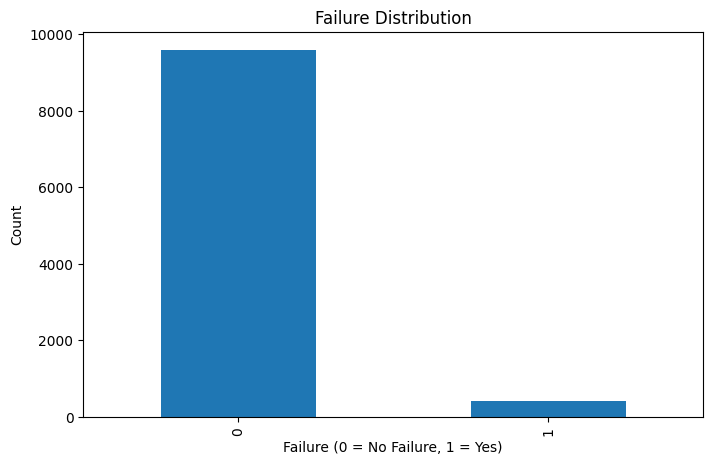

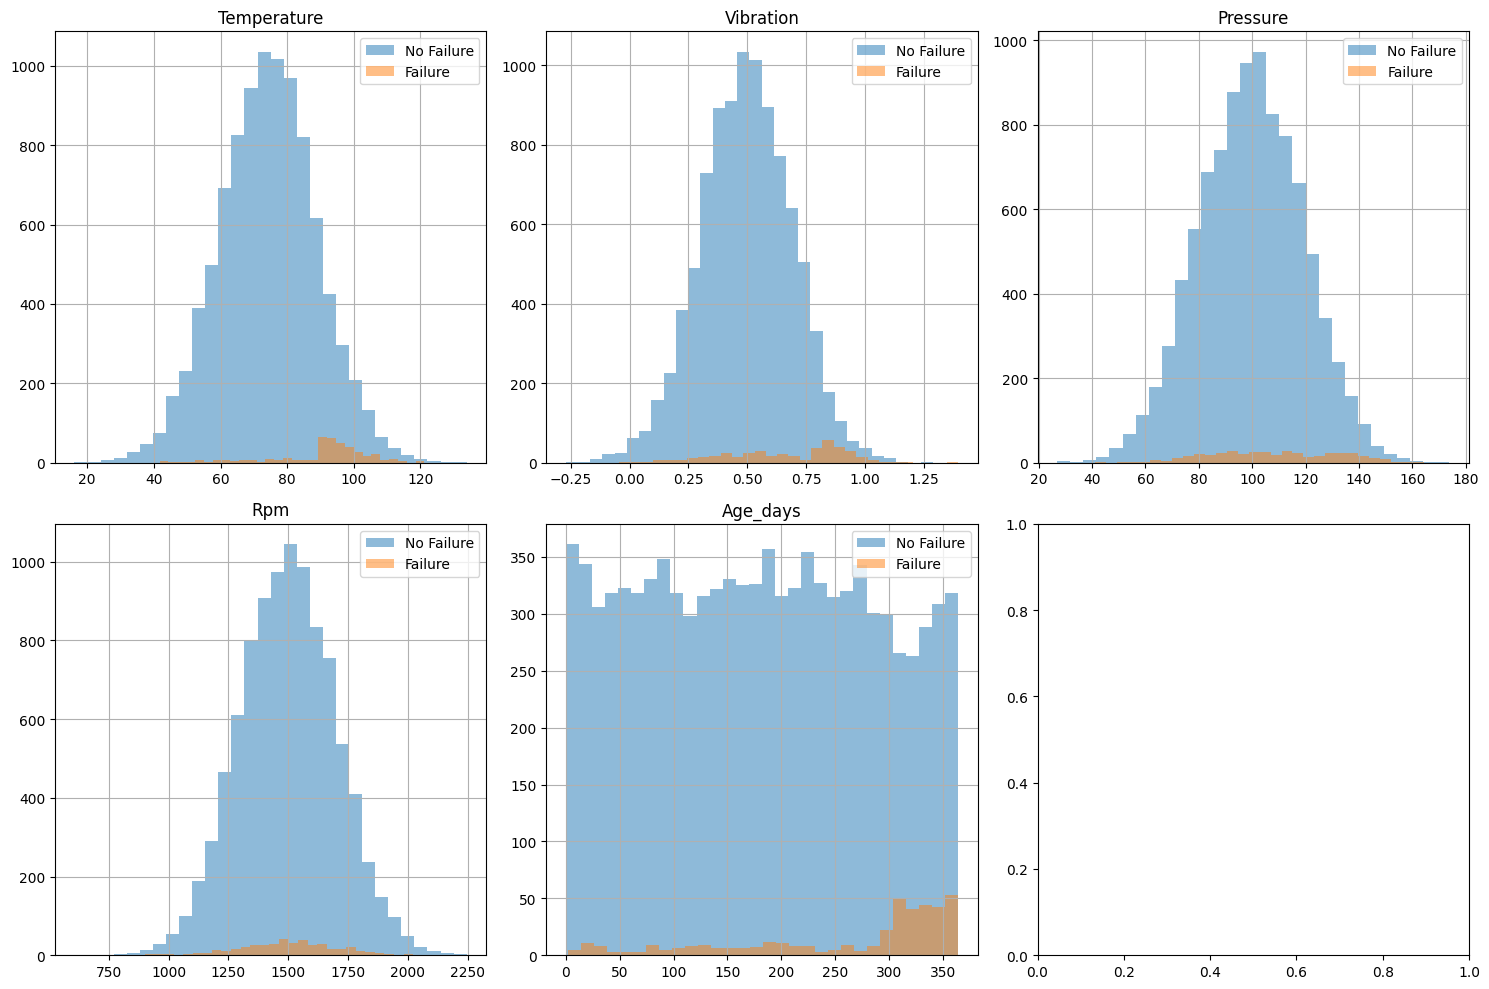

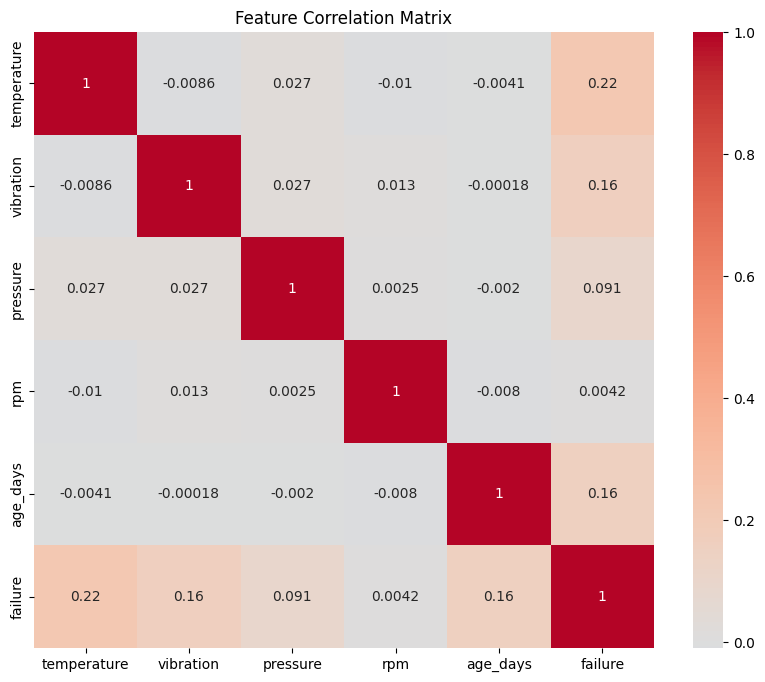

In [7]:
# ========================
# EXPLORATORY DATA ANALYSIS
# ========================

# Summary statistics
print('\nSummary Statistics:')
print(data.describe())

# Check for missing values
print('\nMissing values:')
print(data.isnull().sum())

# Class distribution
plt.figure(figsize=(8, 5))
data.failure.value_counts().plot(kind='bar')
plt.title('Failure Distribution')
plt.xlabel('Failure (0 = No Failure, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['temperature', 'vibration', 'pressure', 'rpm', 'age_days']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    data[data.failure == 0][feature].hist(ax=ax, alpha=0.5, label='No Failure', bins=30)
    data[data.failure == 1][feature].hist(ax=ax, alpha=0.5, label='Failure', bins=30)
    ax.set_title(feature.capitalize())
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [9]:
# After creating your 'data' DataFrame
data.to_csv('artificial_maintenance_data.csv', index=False)
print("✅ Artificial data saved as 'maintenance_data.csv'")
print(f"Shape: {data.shape}")

✅ Artificial data saved as 'maintenance_data.csv'
Shape: (10000, 6)
